In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_test'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_512'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_2'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/01_ex_con_2025_full_wide_ltor'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/02_ex_con_2025_full_wide_ltor_beta_2times')]

In [5]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

In [3]:
scenario_name = "02_ex_con_2025_full_wide_ltor_beta_2times"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [4]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0',  'root_area_index', 'wcont_sigma_deviation','g_bark', 'vmax25' , 'jmax25']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [5]:
post_path

'/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/02_ex_con_2025_full_wide_ltor_beta_2times/post'

In [5]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
df_grp = df.groupby(['id'])[vars].mean()

In [6]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
22277,2,4374,4455,1800.0,1800,False,1.0,1.75,Weibull,29.928822,...,1.774273,1.917793,1.088832,1.235229,1.061170,1.010868,1.245799,1.004739,1.026498,2
22276,1,6259,4455,1800.0,1800,False,1.0,1.75,Weibull,33.397131,...,3.005805,3.219773,1.888918,2.072274,1.861411,1.822535,2.124211,1.004739,1.026498,1
22278,3,6755,4455,1800.0,1800,False,1.0,1.75,Weibull,32.822663,...,6.264284,6.428870,3.828074,4.076862,3.798526,3.782079,4.253678,1.004739,1.026498,3
22279,4,9454,4455,1800.0,1800,False,1.0,1.75,Weibull,39.670843,...,6.254589,6.419119,4.092892,4.362211,4.069056,4.048252,4.483891,1.004739,1.026498,4
22275,0,1482,4455,1800.0,1800,False,1.0,1.75,Weibull,30.882801,...,0.334879,0.374216,0.486170,0.493567,0.558463,0.457045,0.492719,1.004739,1.026498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14290,0,2275,2858,1800.0,1800,False,1.0,1.75,Weibull,35.657627,...,0.525416,0.499761,0.519580,0.511988,0.585183,0.484759,0.527958,1.026953,1.099912,0
14291,1,7223,2858,1800.0,1800,False,1.0,1.75,Weibull,34.057691,...,3.139824,3.394098,1.968389,2.152906,1.941696,1.901515,2.216365,1.026953,1.099912,1
14293,3,9486,2858,1800.0,1800,False,1.0,1.75,Weibull,32.448614,...,3.292086,3.541428,2.025865,2.208756,2.000034,1.959496,2.285349,1.026953,1.099912,3
14292,2,2232,2858,1800.0,1800,False,1.0,1.75,Weibull,33.833953,...,1.939841,2.056375,1.123439,1.266012,1.109407,1.054277,1.295172,1.026953,1.099912,2


In [7]:
df.loc[df['sid'] == 3,'sid']= 4
df.loc[df['sid'] == 2,'sid']= 3
df['sid']

22277    3
22276    1
22278    4
22279    4
22275    0
        ..
14290    0
14291    1
14293    4
14292    3
14294    4
Name: sid, Length: 1420, dtype: int64

In [8]:
dead_ids =[0,3,6,7]
dfs =df[df['sid'] == 0]
dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
dfs.to_csv(os.path.join(post_path, "Alive.csv"))
for i in range(1,5):
    dfs =df[df['sid'] == i]
    dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)
    dfs.to_csv(os.path.join(post_path, f"Dead{i}.csv"))

/tmp/ipykernel_3612024/984454782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
/tmp/ipykernel_3612024/984454782.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)


In [9]:
for var in vars:
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.hist(df_grp[var], alpha=1.0, bins = 20)
    ax.set_xlabel(var)
    plt.savefig(f"{post_path}/mean_hist_{var}.png")
    plt.close(fig)

In [10]:
dv = df[vars]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/tmp/ipykernel_3612024/3013431960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [18]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
22277,2,4374,4455,1800.0,1800,False,1.0,1.75,Weibull,29.928822,...,1.774273,1.917793,1.088832,1.235229,1.061170,1.010868,1.245799,1.004739,1.026498,3
22276,1,6259,4455,1800.0,1800,False,1.0,1.75,Weibull,33.397131,...,3.005805,3.219773,1.888918,2.072274,1.861411,1.822535,2.124211,1.004739,1.026498,1
22278,3,6755,4455,1800.0,1800,False,1.0,1.75,Weibull,32.822663,...,6.264284,6.428870,3.828074,4.076862,3.798526,3.782079,4.253678,1.004739,1.026498,4
22279,4,9454,4455,1800.0,1800,False,1.0,1.75,Weibull,39.670843,...,6.254589,6.419119,4.092892,4.362211,4.069056,4.048252,4.483891,1.004739,1.026498,4
22275,0,1482,4455,1800.0,1800,False,1.0,1.75,Weibull,30.882801,...,0.334879,0.374216,0.486170,0.493567,0.558463,0.457045,0.492719,1.004739,1.026498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14290,0,2275,2858,1800.0,1800,False,1.0,1.75,Weibull,35.657627,...,0.525416,0.499761,0.519580,0.511988,0.585183,0.484759,0.527958,1.026953,1.099912,0
14291,1,7223,2858,1800.0,1800,False,1.0,1.75,Weibull,34.057691,...,3.139824,3.394098,1.968389,2.152906,1.941696,1.901515,2.216365,1.026953,1.099912,1
14293,3,9486,2858,1800.0,1800,False,1.0,1.75,Weibull,32.448614,...,3.292086,3.541428,2.025865,2.208756,2.000034,1.959496,2.285349,1.026953,1.099912,4
14292,2,2232,2858,1800.0,1800,False,1.0,1.75,Weibull,33.833953,...,1.939841,2.056375,1.123439,1.266012,1.109407,1.054277,1.295172,1.026953,1.099912,3


In [19]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,g_bark,vmax25,jmax25,sid
22277,0.442036,-0.192428,-0.437449,-1.365020,1.510549,-0.556426,-1.790082,-0.075812,-0.191926,-0.786419,-1.040987,1.225906,0.528779,-0.253065,0.773514,1.868176,-1.037406,-1.779459,3
22276,0.753781,0.211493,-0.811818,-1.230434,1.399554,-0.122263,-1.765978,0.676219,-0.392301,-0.456607,1.488291,-1.034720,-0.911347,1.210558,-0.077364,1.039199,-0.570365,-1.069706,1
22278,0.202515,-0.539437,-0.601423,-1.143722,1.475966,-0.233499,0.963614,0.523355,-0.291228,-0.745492,-1.033132,0.109216,0.801670,-0.307418,-0.498815,1.107485,-0.647723,-1.212209,4
22279,-3.673519,-0.234199,-1.035047,-1.603134,0.490829,-0.385444,1.010386,0.036754,-0.240358,-0.135141,1.749505,0.353729,-0.397536,0.065614,-0.292745,1.828076,0.274448,-1.766707,4
22275,0.646355,-0.643606,-1.240318,-1.209529,0.105342,-0.511813,-1.086346,1.603433,-0.065748,-0.244853,1.153689,1.192461,2.118129,1.121686,1.598394,1.373566,-0.908943,0.775221,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14290,0.443509,1.790426,-0.429814,-0.580910,-0.388463,-0.440655,0.638330,-1.016950,-0.947685,0.020657,-1.644163,1.039946,1.896253,0.517950,1.077936,1.064911,-0.265969,0.639359,0
14291,0.474447,1.631242,0.569108,-1.081689,-0.251222,-0.826230,-0.239727,-0.329506,-1.192757,-0.615867,-0.276063,-1.068312,-0.352255,0.009741,-0.168046,1.348572,-0.481415,0.379413,1
14293,0.503327,1.338845,1.156318,-0.600232,1.023552,-0.751595,0.446688,-0.428350,-1.279298,-0.425071,-0.520324,-1.267183,-0.102464,0.335772,-1.423551,1.479567,-0.698092,-0.830012,4
14292,0.002735,1.567849,1.476024,-0.154347,1.146272,-0.610839,-0.080698,-0.895106,-1.021982,-0.672020,-1.611727,0.583261,0.640708,1.164657,0.039273,1.091263,-0.511543,1.790194,3


ValueError: operands could not be broadcast together with shapes (324,) (162,) 

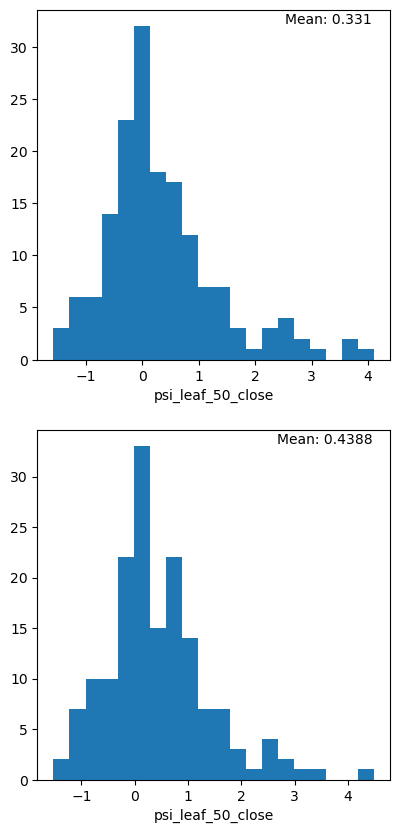

In [23]:
for var in vars:
   #if (var == 'id') | (var == 'sid'):
   #     continue        
    fig = plt.figure(figsize=(10,10))
    for sid in [1,3,4]:
        dfh = pd.DataFrame()
        dfh[var] = df_norm[df_norm['sid'] == sid][var].values - df_norm[df_norm['sid'] == 0][var].values
        ax = fig.add_subplot(2,2,sid)
        ax.hist(dfh[var], alpha=1.0, bins = 20)
        ax.set_xlabel(var)
        ax.text(0.95, 0.95, f"Mean: {np.round(dfh[var].mean(), 4)}",
        verticalalignment ='bottom',
        horizontalalignment ='right',
        transform = ax.transAxes)
    plt.savefig(f"{post_path}/sid_hist_{var}.png")
    plt.close(fig)